# Predicting Stellar Class — アンサンブルモデル

天体データから `GALAXY` / `QSO` / `STAR` の3クラスを予測する。

- **評価指標**: Balanced Accuracy
- **モデル**: LightGBM + XGBoost + CatBoost のアンサンブル(確率平均)
- **不均衡対策**: クラスバランス化したサンプル重みで学習
- **検証**: StratifiedKFold 3-fold のOOF評価

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

SEED = 42
N_FOLDS = 5

train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")
sample_sub = pd.read_csv("data/sample_submission.csv")

print(train.shape, test.shape)
train.head()

KeyboardInterrupt: 

## 1. 簡単なEDA

クラス分布と、判別に効きそうな `redshift` の分布を確認する。

In [1]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train["class"].value_counts().plot.bar(ax=axes[0], color=["#4c72b0", "#dd8452", "#55a868"])
axes[0].set_title("Class distribution")
axes[0].set_ylabel("count")

for cls, color in zip(["GALAXY", "QSO", "STAR"], ["#4c72b0", "#dd8452", "#55a868"]):
    subset = train.loc[train["class"] == cls, "redshift"]
    axes[1].hist(np.log1p(subset.clip(lower=0)), bins=100, alpha=0.5, label=cls, color=color)
axes[1].set_title("log1p(redshift) by class")
axes[1].legend()

plt.tight_layout()
plt.show()

print(train.groupby("class")["redshift"].describe())

NameError: name 'plt' is not defined

## 2. 特徴量エンジニアリング

- **色指数 (color index)**: 隣接バンドの等級差(`u-g`, `g-r`, `r-i`, `i-z`)は天体分類の定番特徴量
- 広いバンド間の差(`u-r`, `g-i`, `u-z`)も追加
- `redshift` は分布が裾広がりなので `log1p` 変換版も追加
- カテゴリ列(`spectral_type`, `galaxy_population`)はラベルエンコードし、LightGBM / CatBoost にはカテゴリとして渡す
- `alpha` / `delta`(天球座標)は本来クラスと無関係のはずだが、念のため残してモデルに判断させる

In [3]:
CAT_COLS = ["spectral_type", "galaxy_population"]


def build_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # 色指数(隣接バンド)
    out["u_g"] = out["u"] - out["g"]
    out["g_r"] = out["g"] - out["r"]
    out["r_i"] = out["r"] - out["i"]
    out["i_z"] = out["i"] - out["z"]
    # 広いバンド間
    out["u_r"] = out["u"] - out["r"]
    out["g_i"] = out["g"] - out["i"]
    out["u_z"] = out["u"] - out["z"]

    out["redshift_log1p"] = np.log1p(out["redshift"].clip(lower=0))

    return out


# カテゴリ列はtrain/test共通のエンコーダで数値化
cat_encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    le.fit(pd.concat([train[col], test[col]]))
    cat_encoders[col] = le

train_fe = build_features(train)
test_fe = build_features(test)
for col, le in cat_encoders.items():
    train_fe[col] = le.transform(train_fe[col])
    test_fe[col] = le.transform(test_fe[col])

FEATURES = [c for c in train_fe.columns if c not in ("id", "class")]

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(train_fe["class"])
X = train_fe[FEATURES]
X_test = test_fe[FEATURES]

# balanced accuracy向けにクラスバランス化した重み
sample_weight = compute_sample_weight("balanced", y)

print("features:", FEATURES)
print("classes:", list(target_encoder.classes_))

features: ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'spectral_type', 'galaxy_population', 'u_g', 'g_r', 'r_i', 'i_z', 'u_r', 'g_i', 'u_z', 'redshift_log1p']
classes: ['GALAXY', 'QSO', 'STAR']


## 3. 学習(3-fold CV + 6モデル)

各foldで LightGBM / XGBoost / CatBoost / ExtraTrees / LightGBM(alt) / XGBoost(alt) を学習し、

- OOF(out-of-fold)予測確率 → アンサンブルの検証用
- テストデータへの予測確率(fold平均) → 提出用

をそれぞれ貯める。早期終了(early stopping)で過学習を抑える。

In [4]:
from catboost import Pool

N_CLASSES = len(target_encoder.classes_)
MODEL_NAMES = ["lgbm", "xgb", "cat", "et", "lgbm_alt", "xgb_alt"]

oof = {m: np.zeros((len(X), N_CLASSES)) for m in MODEL_NAMES}
pred_test = {m: np.zeros((len(X_test), N_CLASSES)) for m in MODEL_NAMES}

# fold内バイアス最適化用に、foldごとの予測を保持
oof_fold = {m: [] for m in MODEL_NAMES}
pred_test_fold = {m: [] for m in MODEL_NAMES}
va_indices = []
y_valid_folds = []

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y)):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y[tr_idx], y[va_idx]
    w_tr, w_va = sample_weight[tr_idx], sample_weight[va_idx]

    # ---- LightGBM ----
    lgbm_model = lgb.LGBMClassifier(
        objective="multiclass",
        n_estimators=2000,
        learning_rate=0.05,
        num_leaves=127,
        colsample_bytree=0.8,
        subsample=0.8,
        subsample_freq=1,
        random_state=SEED,
        n_jobs=-1,
        verbosity=-1,
    )
    lgbm_model.fit(
        X_tr, y_tr,
        sample_weight=w_tr,
        eval_set=[(X_va, y_va)],
        eval_sample_weight=[w_va],
        categorical_feature=CAT_COLS,
        callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)],
    )
    lgbm_va = lgbm_model.predict_proba(X_va)
    lgbm_test = lgbm_model.predict_proba(X_test)
    oof["lgbm"][va_idx] = lgbm_va
    pred_test["lgbm"] += lgbm_test / N_FOLDS
    oof_fold["lgbm"].append(lgbm_va)
    pred_test_fold["lgbm"].append(lgbm_test)

    # ---- XGBoost ----
    xgb_model = xgb.XGBClassifier(
        objective="multi:softprob",
        n_estimators=2000,
        learning_rate=0.05,
        max_depth=8,
        colsample_bytree=0.8,
        subsample=0.8,
        tree_method="hist",
        device="cuda",
        early_stopping_rounds=100,
        random_state=SEED,
        n_jobs=-1,
        verbosity=0,
    )
    xgb_model.fit(
        X_tr, y_tr,
        sample_weight=w_tr,
        eval_set=[(X_va, y_va)],
        sample_weight_eval_set=[w_va],
        verbose=False,
    )
    xgb_va = xgb_model.predict_proba(X_va)
    xgb_test = xgb_model.predict_proba(X_test)
    oof["xgb"][va_idx] = xgb_va
    pred_test["xgb"] += xgb_test / N_FOLDS
    oof_fold["xgb"].append(xgb_va)
    pred_test_fold["xgb"].append(xgb_test)

    # ---- CatBoost ----
    cat_feature_idx = [FEATURES.index(c) for c in CAT_COLS]
    cat_model = CatBoostClassifier(
        loss_function="MultiClass",
        iterations=2000,
        learning_rate=0.08,
        depth=8,
        random_seed=SEED,
        early_stopping_rounds=100,
        task_type="GPU",
        devices="0",
        verbose=0,
    )
    cat_model.fit(
        Pool(X_tr, y_tr, weight=w_tr, cat_features=cat_feature_idx),
        eval_set=Pool(X_va, y_va, weight=w_va, cat_features=cat_feature_idx),
    )
    cat_va = cat_model.predict_proba(X_va)
    cat_test = cat_model.predict_proba(X_test)
    oof["cat"][va_idx] = cat_va
    pred_test["cat"] += cat_test / N_FOLDS
    oof_fold["cat"].append(cat_va)
    pred_test_fold["cat"].append(cat_test)

    # ---- ExtraTrees ----
    et_model = ExtraTreesClassifier(
        n_estimators=600,
        max_depth=None,
        min_samples_leaf=2,
        max_features="sqrt",
        n_jobs=-1,
        random_state=SEED,
    )
    et_model.fit(X_tr, y_tr, sample_weight=w_tr)
    et_va = et_model.predict_proba(X_va)
    et_test = et_model.predict_proba(X_test)
    oof["et"][va_idx] = et_va
    pred_test["et"] += et_test / N_FOLDS
    oof_fold["et"].append(et_va)
    pred_test_fold["et"].append(et_test)

    # ---- LightGBM (alt) ----
    lgbm_alt_model = lgb.LGBMClassifier(
        objective="multiclass",
        n_estimators=2200,
        learning_rate=0.04,
        num_leaves=255,
        max_depth=-1,
        min_child_samples=40,
        colsample_bytree=0.9,
        subsample=0.9,
        subsample_freq=1,
        random_state=SEED + 101,
        n_jobs=-1,
        verbosity=-1,
    )
    lgbm_alt_model.fit(
        X_tr,
        y_tr,
        sample_weight=w_tr,
        eval_set=[(X_va, y_va)],
        eval_sample_weight=[w_va],
        categorical_feature=CAT_COLS,
        callbacks=[lgb.early_stopping(120, verbose=False), lgb.log_evaluation(0)],
    )
    lgbm_alt_va = lgbm_alt_model.predict_proba(X_va)
    lgbm_alt_test = lgbm_alt_model.predict_proba(X_test)
    oof["lgbm_alt"][va_idx] = lgbm_alt_va
    pred_test["lgbm_alt"] += lgbm_alt_test / N_FOLDS
    oof_fold["lgbm_alt"].append(lgbm_alt_va)
    pred_test_fold["lgbm_alt"].append(lgbm_alt_test)

    # ---- XGBoost (alt) ----
    xgb_alt_model = xgb.XGBClassifier(
        objective="multi:softprob",
        n_estimators=2200,
        learning_rate=0.04,
        max_depth=10,
        min_child_weight=2,
        gamma=0.0,
        colsample_bytree=0.9,
        subsample=0.9,
        tree_method="hist",
        device="cuda",
        early_stopping_rounds=120,
        random_state=SEED + 202,
        n_jobs=-1,
        verbosity=0,
    )
    xgb_alt_model.fit(
        X_tr,
        y_tr,
        sample_weight=w_tr,
        eval_set=[(X_va, y_va)],
        sample_weight_eval_set=[w_va],
        verbose=False,
    )
    xgb_alt_va = xgb_alt_model.predict_proba(X_va)
    xgb_alt_test = xgb_alt_model.predict_proba(X_test)
    oof["xgb_alt"][va_idx] = xgb_alt_va
    pred_test["xgb_alt"] += xgb_alt_test / N_FOLDS
    oof_fold["xgb_alt"].append(xgb_alt_va)
    pred_test_fold["xgb_alt"].append(xgb_alt_test)

    va_indices.append(va_idx)
    y_valid_folds.append(y_va)

    scores = {
        m: balanced_accuracy_score(y_va, oof[m][va_idx].argmax(axis=1))
        for m in MODEL_NAMES
    }
    print(f"fold {fold}: " + ", ".join(f"{m}={s:.5f}" for m, s in scores.items()))

for m in MODEL_NAMES:
    print(f"OOF balanced accuracy [{m}]: {balanced_accuracy_score(y, oof[m].argmax(axis=1)):.5f}")

fold 0: lgbm=0.96483, xgb=0.96470, cat=0.96269, et=0.94767, lgbm_alt=0.96482, xgb_alt=0.96397


fold 1: lgbm=0.96425, xgb=0.96364, cat=0.96224, et=0.94728, lgbm_alt=0.96373, xgb_alt=0.96301


fold 2: lgbm=0.96356, xgb=0.96319, cat=0.96176, et=0.94769, lgbm_alt=0.96350, xgb_alt=0.96242
OOF balanced accuracy [lgbm]: 0.96421
OOF balanced accuracy [xgb]: 0.96385
OOF balanced accuracy [cat]: 0.96223
OOF balanced accuracy [et]: 0.94755
OOF balanced accuracy [lgbm_alt]: 0.96402
OOF balanced accuracy [xgb_alt]: 0.96314


## 4. アンサンブル

6モデルの予測確率を重み付き平均する。重みはOOFのbalanced accuracyが最大になる組み合わせをグリッドサーチで決める。

n_weight_candidates: 3003
best weights (lgbm, xgb, cat, et, lgbm_alt, xgb_alt) = (0.2, 0.5, 0.0, 0.0, 0.30000000000000004, 0.0)
ensemble OOF balanced accuracy (base) = 0.96458


fold 0 best bias = [-0.06, 0.020000000000000018, 0.020000000000000018], score = 0.96558


fold 1 best bias = [-0.06, 0.05000000000000002, 0.060000000000000026], score = 0.96468


fold 2 best bias = [-0.06, -0.039999999999999994, 0.060000000000000026], score = 0.96444
ensemble OOF balanced accuracy (bias-corrected) = 0.96490
mean fold bias: [-0.06, 0.010000000000000014, 0.04666666666666669]


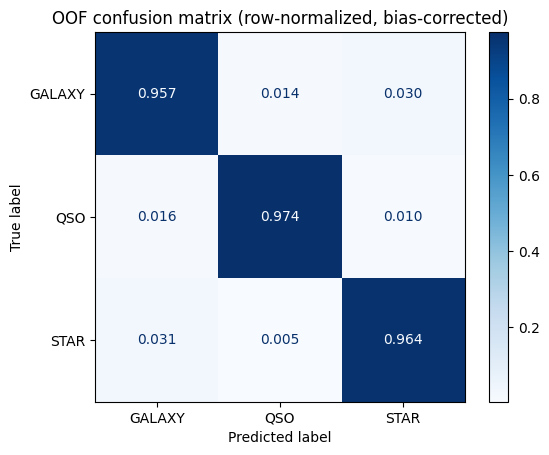

In [5]:
from itertools import product

# 1) モデル重みをOOFで最適化（6モデルでも実用速度になるよう候補を直接生成）
def generate_weight_candidates(num_models, total_steps=10):
    if num_models == 1:
        yield (total_steps,)
        return
    for i in range(total_steps + 1):
        for tail in generate_weight_candidates(num_models - 1, total_steps - i):
            yield (i,) + tail


best_weights, best_score = None, -1.0
weight_step = 0.1
weight_candidates = [tuple(v * weight_step for v in ints) for ints in generate_weight_candidates(len(MODEL_NAMES), int(round(1.0 / weight_step)))]

for weights in weight_candidates:
    blend = sum(w * oof[m] for w, m in zip(weights, MODEL_NAMES))
    score = balanced_accuracy_score(y, blend.argmax(axis=1))
    if score > best_score:
        best_score = score
        best_weights = weights

print("n_weight_candidates:", len(weight_candidates))
print(f"best weights ({', '.join(MODEL_NAMES)}) = {best_weights}")
print(f"ensemble OOF balanced accuracy (base) = {best_score:.5f}")

# 2) foldごとにバイアス最適化（log(prob)+bias）
def find_best_bias(log_proba, y_true, bias_grid):
    best_bias = np.zeros(log_proba.shape[1])
    best_score_local = -1.0
    for bias in product(bias_grid, repeat=log_proba.shape[1]):
        bias = np.array(bias)
        pred_tmp = (log_proba + bias).argmax(axis=1)
        s = balanced_accuracy_score(y_true, pred_tmp)
        if s > best_score_local:
            best_score_local = s
            best_bias = bias.copy()
    return best_bias, best_score_local


def apply_log_bias_to_proba(proba, bias):
    adj = np.exp(np.log(np.clip(proba, 1e-15, 1.0)) + bias)
    return adj / adj.sum(axis=1, keepdims=True)


oof_blend_base = sum(w * oof[m] for w, m in zip(best_weights, MODEL_NAMES))
oof_pred_base = oof_blend_base.argmax(axis=1)

bias_grid = np.arange(-0.06, 0.061, 0.01)
fold_biases = []

oof_blend_bias = np.zeros((len(X), N_CLASSES))
test_blend_bias = np.zeros((len(X_test), N_CLASSES))

for fold in range(N_FOLDS):
    va_idx = va_indices[fold]
    y_va = y_valid_folds[fold]

    va_blend = sum(w * oof_fold[m][fold] for w, m in zip(best_weights, MODEL_NAMES))
    test_blend_fold = sum(w * pred_test_fold[m][fold] for w, m in zip(best_weights, MODEL_NAMES))

    best_bias, best_score_fold = find_best_bias(np.log(np.clip(va_blend, 1e-15, 1.0)), y_va, bias_grid)
    fold_biases.append(best_bias)

    oof_blend_bias[va_idx] = apply_log_bias_to_proba(va_blend, best_bias)
    test_blend_bias += apply_log_bias_to_proba(test_blend_fold, best_bias) / N_FOLDS

    print(f"fold {fold} best bias = {best_bias.tolist()}, score = {best_score_fold:.5f}")

oof_pred = oof_blend_bias.argmax(axis=1)
score_bias = balanced_accuracy_score(y, oof_pred)

print(f"ensemble OOF balanced accuracy (bias-corrected) = {score_bias:.5f}")
print("mean fold bias:", np.mean(np.stack(fold_biases), axis=0).tolist())

# 提出時に使う最終ブレンド（fold内バイアス補正済み）
test_blend = test_blend_bias

cm = confusion_matrix(y, oof_pred, normalize="true")
disp = ConfusionMatrixDisplay(cm, display_labels=target_encoder.classes_)
disp.plot(cmap="Blues", values_format=".3f")
plt.title("OOF confusion matrix (row-normalized, bias-corrected)")
plt.show()

## 5. スタッキング（OOFメタ学習）

6モデルのOOF確率を特徴量として、2層目のロジスティック回帰を学習する。
メタ層もfoldで学習し、OOFとtest予測を作る。

## 6. 提出ファイル作成

スタッキングで得た `test_blend` から最終クラスを作成して `submission.csv` を出力する。

In [6]:
# OOF確率をメタ特徴量へ変換
meta_features = np.concatenate([oof[m] for m in MODEL_NAMES], axis=1)
meta_test_features = np.concatenate([pred_test[m] for m in MODEL_NAMES], axis=1)

# メタ層CV（リーク回避のためfoldで学習）
meta_oof = np.zeros((len(X), N_CLASSES))
meta_test = np.zeros((len(X_test), N_CLASSES))

meta_skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED + 999)
for fold, (tr_idx, va_idx) in enumerate(meta_skf.split(meta_features, y)):
    X_meta_tr, X_meta_va = meta_features[tr_idx], meta_features[va_idx]
    y_meta_tr, y_meta_va = y[tr_idx], y[va_idx]

    meta_model = LogisticRegression(
        max_iter=4000,
        multi_class="multinomial",
        class_weight="balanced",
        n_jobs=-1,
        C=2.0,
        random_state=SEED + 999 + fold,
    )
    meta_model.fit(X_meta_tr, y_meta_tr)

    meta_oof[va_idx] = meta_model.predict_proba(X_meta_va)
    meta_test += meta_model.predict_proba(meta_test_features) / N_FOLDS

meta_score = balanced_accuracy_score(y, meta_oof.argmax(axis=1))
print(f"stacking OOF balanced accuracy = {meta_score:.5f}")

# スタッキング結果を最終提出に使用
test_blend = meta_test

cm_stack = confusion_matrix(y, meta_oof.argmax(axis=1), normalize="true")
disp_stack = ConfusionMatrixDisplay(cm_stack, display_labels=target_encoder.classes_)
disp_stack.plot(cmap="Blues", values_format=".3f")
plt.title("OOF confusion matrix (stacking)")
plt.show()

test_pred = target_encoder.inverse_transform(test_blend.argmax(axis=1))

submission = pd.DataFrame({"id": test_fe["id"], "class": test_pred})
assert (submission["id"].values == sample_sub["id"].values).all()
submission.to_csv("submission.csv", index=False)

print(submission["class"].value_counts())
submission.head()

class
GALAXY    156926
QSO        51243
STAR       39266
Name: count, dtype: int64


,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY
